# Evaluation on trained models

In [1]:
# mainly loading the environment used for training. Unify everything. (run context)
from dirs import *
from train import *

c:\Users\qiyuanxu\Documents\GitHub\fiber-image-reconstruction-comparison


c:\Users\qiyuanxu\AppData\Local\miniconda3\envs\torch\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Prepare
Manually handle the practical complexity, by loading different trained models and prepare relavant evaluation dataset 

Falling back to list dataset because tensors could not be stacked: Non-tensor component detected


Samples:  1000
Batch:  32


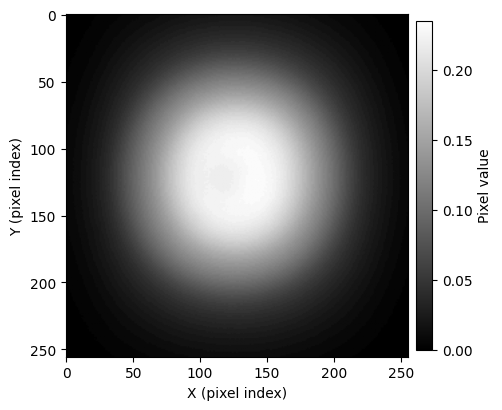

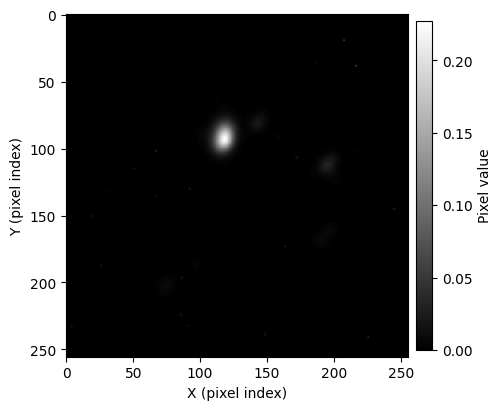

In [2]:
""" 2025 CLEAR CAE trained on real beam chromox line scan + SGM """

# ========================================
# Load model
# ========================================
import torch
from models.CAE import Autoencoder2D

# chromox_cae_random_scan; chromox_cropped_cae_line_scan_sgm; chromox_cropped_cae_random_scan; chromox_cropped_cae_random_scan_leakless 
# Model_trained_on_CHROMOX_only; Model_trained_on_CHROMOX_LASER_only; 
model_name = "Model_trained_on_CHROMOX_LASER_only"    
model_path = dirs["models"][model_name] # should point to model.pth
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Autoencoder2D.load_model(
    filepath=model_path,  # should point to model.pth
    device=device,
    eval_mode=True, # inference mode
)
print(show_model_info(model))

# ========================================
# load dataset for inference
# ========================================
from xflow.utils.visualization import plot_image

experiment_name = "CLEAR25"
# ["processed_dmd", "processed_chromox", "processed_yag", "processed_chromox_laser", "processed_yag_laser", "processed_chromox_cropped", "2025-11-06"]'
dataset_sources = ["processed_chromox"]  

config_manager = ConfigManager(
    load_config(
        f"{experiment_name}.yaml",
        machine=detect_machine(),
        resolve=True,
    )
)
config = config_manager.get()
dataset_dirs = [resolve_dataset_dir(config, src) for src in dataset_sources]
db_rel = config["dataset_structure"]["db"].lstrip("/\\")
db_paths = [d / db_rel for d in dataset_dirs]

eval_provider = SqlProvider(
    sources={"connection": db_paths[0], "sql": config["sql"]["chromox_all"]}, output_config={'list': "image_path"}
).subsample(n_samples=1000, seed=config["seed"])

# pad abs path to db saved relative dirs.
def set_parent_dir_in_node(node, parent_dir, first_only=True):
    if isinstance(node, list):
        for item in node:
            found = set_parent_dir_in_node(item, parent_dir, first_only)
            if found and first_only:
                return True
        return False

    if isinstance(node, dict):
        if node.get("name") == "add_parent_dir":
            node.setdefault("params", {})["parent_dir"] = str(parent_dir)
            if first_only:
                return True

        for v in node.values():
            found = set_parent_dir_in_node(v, parent_dir, first_only)
            if found and first_only:
                return True

    return False
set_parent_dir_in_node(config["inference"]["transforms"]["torch"], dataset_dirs[0], first_only=True)
transforms = build_transforms_from_config(config["inference"]["transforms"]["torch"]) 

# normally leave the pipelines decoupled and untouched so the output interface remains consistent.
eval_dataset = PyTorchPipeline(
    eval_provider,
    transforms,
    skip_errors=False,  # skip errors during inference
).to_memory_dataset(config["data"]["dataset_ops"])  # testset data do not need thresholding since it is to remove stacking noise?

print("Samples: ", len(eval_provider))
print("Batch: ", len(eval_dataset))
# plot_image(next(iter(eval_dataset))[0])
# plot_image(next(iter(eval_dataset))[1])

batch = next(iter(eval_dataset))
x = batch[0] # list of 2 tensors
i = 0 # sample index in batch
plot_image(x[0][i]) # branch 0, sample i
plot_image(x[1][i]) # branch 1, sample i

# Inference
get and save intermediate result, fixed downstream (mainly plotting) contract

In [3]:
"""
MMF speckle reconstruction inference with per-sample image triplets saved to disk.

Ported from the old flat script. The domain-specific logic (triplet figure
saving) lives in TripletSaverHook; the runner handles iteration, device,
eval mode, and batch unpacking.
"""
import os

from xflow.evaluation.runner import (
    run_evaluation,
    TqdmHook,
)
from xflow.extensions.physics.runner import TripletSaverHook, BeamParamCSVHook

# ----------------------------
# Entry point
# ----------------------------
# Expected to be defined in the surrounding notebook / script:
#   model, eval_dataset, device, dirs, model_name


def unpack_batch(raw):
    """
    eval_dataset yields (image_payload, metadata) where:
      image_payload = [inputs_tensor, targets_tensor]  (each [B, 1, 256, 256])
      metadata      = tuple[str, ...] of length B      (filenames)
    """
    x_list, meta = raw
    inputs, targets = x_list
    return inputs, targets, meta

save_dir = dirs["save"]["model_inference"][model_name]
saver = TripletSaverHook(save_dir=save_dir)
beam_csv = BeamParamCSVHook(
    csv_path=os.path.join(save_dir, "beam_parameters.csv"),
    methods=("moments", "gaussian"),
    append=True,
    flush_every=256,
)
ctx = run_evaluation(
    model=model,
    dataset=eval_dataset,
    device=device,
    hooks=[TqdmHook(), saver, beam_csv],
    unpack_batch=unpack_batch,
)

print(f"batches: {ctx.seen_batches}, samples: {ctx.seen_samples}")
print(f"beam parameters saved to: {os.path.join(save_dir, 'beam_parameters.csv')}")

Evaluation:   3%|▎         | 1/32 [00:05<02:47,  5.40s/batch]C:\Users\qiyuanxu\Documents\GitHub\XFlow\src\xflow\extensions\physics\beam.py:340: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(
Evaluation:  28%|██▊       | 9/32 [03:02<08:32, 22.28s/batch]C:\Users\qiyuanxu\Documents\GitHub\XFlow\src\xflow\extensions\physics\beam.py:340: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(
Evaluation:  53%|█████▎    | 17/32 [05:59<05:31, 22.08s/batch]C:\Users\qiyuanxu\Documents\GitHub\XFlow\src\xflow\extensions\physics\beam.py:340: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(
Evaluation:  78%|███████▊  | 25/32 [08:59<02:34, 22.06s/batch]C:\Users\qiyuanxu\Documents\GitHub\XFlow\src\xflow\extensions\physics\beam.py:340: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(
Evaluation: 100%|██████████| 32/32 [11:41<00:00, 21.93

saved: 1000 images to C:/Users/qiyuanxu/Desktop/Models/Scope 1 cross field/Model_trained_on_CHROMOX_LASER_only/inference/
saved: 1000 beam-parameter rows to C:/Users/qiyuanxu/Desktop/Models/Scope 1 cross field/Model_trained_on_CHROMOX_LASER_only/inference/beam_parameters.csv
batches: 32, samples: 1000
beam parameters saved to: C:/Users/qiyuanxu/Desktop/Models/Scope 1 cross field/Model_trained_on_CHROMOX_LASER_only/inference/beam_parameters.csv


# Visualization
Completely decoupled from above, read only intermediate results with fixed contract, only focus on high quality publication level image, each block is one plot

In [6]:
"""Resuable components, Run once for all evaluations"""

import pandas as pd
from dirs import *

def load_beam_param_df(csv_path):
    df = pd.read_csv(csv_path, skipinitialspace=True)
    df.columns = (
        df.columns.astype(str)
        .str.replace("\ufeff", "", regex=False)
        .str.strip()
    )
    return df

# =========================================================
# Generic NaN/inf row cleaner
# Drops any row containing NaN or ±inf in any column.
# Returns a new df; original is untouched.
# =========================================================

def drop_invalid_rows(df):
    mask = df.replace([np.inf, -np.inf], np.nan).notna().all(axis=1)
    return df.loc[mask].reset_index(drop=True)

_DIMS_PARAMS = [
    ("h", "centroid"),
    ("v", "centroid"),
    ("h", "width"),
    ("v", "width"),
]

"""Specific model to be evaluated, which guides the downstream plot to find the right folder"""
# chromox_cae_random_scan; chromox_cropped_cae_line_scan_sgm; chromox_cropped_cae_random_scan; chromox_cropped_cae_random_scan_leakless
# Model_trained_on_CHROMOX_only; Model_trained_on_CHROMOX_LASER_only； Model_trained_on_DMD_orth_SGM_inLab_150MB
MODEL_NAME = "Model_trained_on_CHROMOX_LASER_only"

## Classic three statistical plots on testset
(Scatter plot, residual plot and error distribution histogram)

In [7]:
# Classic three statistical plots on testset
# (Scatter plot, residual plot, and residual histogram)
# Includes centroid, width, and core_sigma -> total 9 plots.

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xflow.extensions.style.aps import APS_COLORS, set_aps_double_column

# =========================================================
# Data utilities
# =========================================================

def _col_names(fit_method, param_type, dim):
    """
    Two naming modes:

    1) fit-based (existing):
       label_{fit_method}_{dim}_{param_type}
       reconstructed_{fit_method}_{dim}_{param_type}
       e.g. label_gaussian_h_centroid

    2) direct (new core sigma):
       label_{dim}_{param_type}
       reconstructed_{dim}_{param_type}
       e.g. label_h_core_sigma
    """
    param_type = str(param_type).strip().lower()
    dim = str(dim).strip().lower()
    fit_method = "" if fit_method is None else str(fit_method).strip().lower()

    if fit_method:
        gt_col = f"label_{fit_method}_{dim}_{param_type}"
        pred_col = f"reconstructed_{fit_method}_{dim}_{param_type}"
    else:
        gt_col = f"label_{dim}_{param_type}"
        pred_col = f"reconstructed_{dim}_{param_type}"

    return gt_col, pred_col


def prepare_plot_df(df, param_type, fit_method, dims=("h", "v")):
    out = df.copy().replace([np.inf, -np.inf], np.nan)

    active_dims = []
    needed_cols = []
    for dim in dims:
        gt_col, pred_col = _col_names(fit_method, param_type, dim)
        if gt_col in out.columns and pred_col in out.columns:
            active_dims.append(dim)
            needed_cols.extend([gt_col, pred_col])

    if not active_dims:
        raise ValueError(
            f"No usable columns for fit_method={fit_method}, param_type={param_type}."
        )

    for c in needed_cols:
        out[c] = pd.to_numeric(out[c], errors="coerce")

    # Keep rows that have at least one valid pair among active dimensions
    valid_mask = np.zeros(len(out), dtype=bool)
    for dim in active_dims:
        gt_col, pred_col = _col_names(fit_method, param_type, dim)
        pair_ok = out[gt_col].notna() & out[pred_col].notna()
        valid_mask |= pair_ok

    out = out.loc[valid_mask].reset_index(drop=True)
    return out, active_dims


def _pair(df, fit_method, param_type, dim):
    gt_col, pred_col = _col_names(fit_method, param_type, dim)
    if gt_col not in df.columns or pred_col not in df.columns:
        return np.array([], dtype=float), np.array([], dtype=float)

    gt = pd.to_numeric(df[gt_col], errors="coerce").to_numpy(dtype=float)
    pred = pd.to_numeric(df[pred_col], errors="coerce").to_numpy(dtype=float)
    m = np.isfinite(gt) & np.isfinite(pred)
    return gt[m], pred[m]


def _new_ax():
    set_aps_double_column(figsize=FIGSIZE, scale=1.0, legend_background=True)
    fig, ax = plt.subplots(figsize=FIGSIZE, constrained_layout=True)
    ax.set_box_aspect(1)

    ax.tick_params(
        axis="both",
        which="major",
        labelsize=TICK_LABEL_SIZE,
        length=TICK_MAJOR_LEN,
        width=TICK_WIDTH,
    )
    ax.tick_params(
        axis="both",
        which="minor",
        length=TICK_MINOR_LEN,
        width=TICK_WIDTH,
    )
    return fig, ax


def _legend(ax):
    ax.legend(
        fontsize=LEGEND_FONT_SIZE,
        frameon=True,
        facecolor="white",
        edgecolor="black",
        framealpha=0.95,
    )


# =========================================================
# Plot 1: Prediction vs Ground Truth
# =========================================================
def plot_pred_vs_label(
    df,
    param_type="centroid",
    fit_method="gaussian",
    dims=("h", "v"),
    xlim=(0.0, 1.0),
    ylim=(0.0, 1.0),
):
    fig, ax = _new_ax()

    for dim in dims:
        gt, pred = _pair(df, fit_method, param_type, dim)
        if gt.size == 0:
            continue

        ax.scatter(
            gt,
            pred,
            s=SCATTER_POINT_SIZE,
            alpha=0.72,
            marker="o",
            color=DIM_STYLE[dim]["color"],
            edgecolors="none",
            label=f"{DIM_STYLE[dim]['name']} {param_type}",
        )

    ax.plot([xlim[0], xlim[1]], [xlim[0], xlim[1]], "--", lw=REF_LINE_WIDTH, color=REF_COLOR)

    ax.set_xlim(xlim[0], xlim[1])
    ax.set_ylim(ylim[0], ylim[1])
    ax.set_aspect("equal", adjustable="box")

    ax.set_xlabel("Ground truth", fontsize=AXIS_LABEL_SIZE)
    ax.set_ylabel("Prediction", fontsize=AXIS_LABEL_SIZE)
    _legend(ax)
    return fig, ax


# =========================================================
# Plot 2: Residual vs Ground Truth (normalized residual)
# residual = pred - gt
# =========================================================
def plot_residual_vs_label(
    df,
    param_type="centroid",
    fit_method="gaussian",
    dims=("h", "v"),
    xlim=(0.0, 1.0),
    ylim=(-1.0, 1.0),
):
    fig, ax = _new_ax()

    for dim in dims:
        gt, pred = _pair(df, fit_method, param_type, dim)
        if gt.size == 0:
            continue

        residual = pred - gt
        residual = np.clip(residual, ylim[0], ylim[1])

        ax.scatter(
            gt,
            residual,
            s=SCATTER_POINT_SIZE,
            alpha=0.72,
            marker="o",
            color=DIM_STYLE[dim]["color"],
            edgecolors="none",
            label=f"{DIM_STYLE[dim]['name']} {param_type}",
        )

    ax.axhline(0.0, ls="--", lw=REF_LINE_WIDTH, color=REF_COLOR)

    ax.set_xlim(xlim[0], xlim[1])
    ax.set_ylim(ylim[0], ylim[1])

    ax.set_xlabel("Ground truth", fontsize=AXIS_LABEL_SIZE)
    ax.set_ylabel("Residual (pred - gt)", fontsize=AXIS_LABEL_SIZE)
    _legend(ax)
    return fig, ax


# =========================================================
# Plot 3: Residual percentage histogram
# residual_pct = (pred - gt) * 100
# x-range fixed by input and clipped
# =========================================================
def plot_residual_hist_pct(
    df,
    param_type="centroid",
    fit_method="gaussian",
    dims=("h", "v"),
    x_range_pct=(-100.0, 100.0),
    bins=40,
    y_max=None,
):
    fig, ax = _new_ax()
    x_min, x_max = float(x_range_pct[0]), float(x_range_pct[1])
    hist_bins = np.linspace(x_min, x_max, int(bins) + 1)

    for dim in dims:
        gt, pred = _pair(df, fit_method, param_type, dim)
        if gt.size == 0:
            continue

        residual_pct = (pred - gt) * 100.0
        residual_pct = residual_pct[np.isfinite(residual_pct)]
        if residual_pct.size == 0:
            continue

        residual_pct = np.clip(residual_pct, x_min, x_max)

        counts, edges, _ = ax.hist(
            residual_pct,
            bins=hist_bins,
            alpha=0.38,
            color=DIM_STYLE[dim]["color"],
            label=f"{DIM_STYLE[dim]['name']} {param_type}",
        )

        # Gaussian fit line
        if residual_pct.size > 1:
            mu = float(np.mean(residual_pct))
            sigma = float(np.std(residual_pct, ddof=1))
            if sigma > 0:
                xfit = np.linspace(edges[0], edges[-1], 300)
                bw = edges[1] - edges[0]
                yfit = (
                    residual_pct.size
                    * bw
                    * (1.0 / (sigma * np.sqrt(2.0 * np.pi)))
                    * np.exp(-0.5 * ((xfit - mu) / sigma) ** 2)
                )
                ax.plot(xfit, yfit, lw=2.0, color=DIM_STYLE[dim]["color"], alpha=0.95)

    ax.axvline(0.0, ls="--", lw=REF_LINE_WIDTH, color=REF_COLOR)
    ax.set_xlim(x_min, x_max)

    if y_max is not None:
        ax.set_ylim(0.0, float(y_max))

    ax.set_xlabel("Residual (%)", fontsize=AXIS_LABEL_SIZE)
    ax.set_ylabel("Count", fontsize=AXIS_LABEL_SIZE)
    _legend(ax)
    return fig, ax


def make_three_plots(
    df,
    param_type="centroid",
    fit_method="gaussian",
    dims=("h", "v"),
    pred_gt_xlim=(0.0, 1.0),
    pred_gt_ylim=(0.0, 1.0),
    residual_xlim=(0.0, 1.0),
    residual_ylim=(-1.0, 1.0),
    hist_x_range_pct=(-100.0, 100.0),
    hist_bins=40,
    hist_y_max=None,
):
    clean_df, active_dims = prepare_plot_df(
        df=df,
        param_type=param_type,
        fit_method=fit_method,
        dims=dims,
    )

    f1, _ = plot_pred_vs_label(
        clean_df,
        param_type=param_type,
        fit_method=fit_method,
        dims=active_dims,
        xlim=pred_gt_xlim,
        ylim=pred_gt_ylim,
    )

    f2, _ = plot_residual_vs_label(
        clean_df,
        param_type=param_type,
        fit_method=fit_method,
        dims=active_dims,
        xlim=residual_xlim,
        ylim=residual_ylim,
    )

    f3, _ = plot_residual_hist_pct(
        clean_df,
        param_type=param_type,
        fit_method=fit_method,
        dims=active_dims,
        x_range_pct=hist_x_range_pct,
        bins=hist_bins,
        y_max=hist_y_max,
    )

    return f1, f2, f3


# =========================================================
# Global controls
# =========================================================

# 3 groups => 9 plots total
# centroid/width use gaussian-prefixed columns
# core_sigma uses direct columns (no fit prefix)
PLOT_SPECS = (
    ("centroid", "gaussian"),
    ("width", "gaussian"),
    ("core_sigma", None),
)

DIMS_TO_USE = ("h", "v")

FIGSIZE = (3.8, 3.8)
SCATTER_POINT_SIZE = 5
REF_LINE_WIDTH = 2.4

TICK_LABEL_SIZE = 11
AXIS_LABEL_SIZE = 12
TITLE_FONT_SIZE = 13
LEGEND_FONT_SIZE = 10
TICK_MAJOR_LEN = 5
TICK_MINOR_LEN = 3
TICK_WIDTH = 1.0

PRED_GT_XLIM = (0.0, 1.0)
PRED_GT_YLIM = (0.0, 1.0)

RESIDUAL_SCATTER_XLIM = (0.0, 1.0)
RESIDUAL_SCATTER_YLIM = (-1.0, 1.0)

HIST_X_RANGE_PCT = (-50.0, 50.0)
HIST_BINS = 50
HIST_Y_MAX = 350

SAVE_PREFIX = "_"

DIM_STYLE = {
    "h": {"name": "Horizontal", "color": APS_COLORS[4]},
    "v": {"name": "Vertical", "color": APS_COLORS[5]},
}
REF_COLOR = APS_COLORS[7]

# =========================================================
# Run + save
# =========================================================
save_dir = dirs["save"]["model_inference"][MODEL_NAME]
csv_path = os.path.join(save_dir, "beam_parameters.csv")
df = load_beam_param_df(csv_path)

for param_type, fit_method in PLOT_SPECS:
    fig1, fig2, fig3 = make_three_plots(
        df=df,
        param_type=param_type,
        fit_method=fit_method,
        dims=DIMS_TO_USE,
        pred_gt_xlim=PRED_GT_XLIM,
        pred_gt_ylim=PRED_GT_YLIM,
        residual_xlim=RESIDUAL_SCATTER_XLIM,
        residual_ylim=RESIDUAL_SCATTER_YLIM,
        hist_x_range_pct=HIST_X_RANGE_PCT,
        hist_bins=HIST_BINS,
        hist_y_max=HIST_Y_MAX,
    )

    tag = f"{fit_method}_{param_type}" if fit_method else param_type

    fig1.savefig(os.path.join(save_dir, f"{SAVE_PREFIX}{tag}_scatter_pred_vs_gt.png"))
    fig2.savefig(os.path.join(save_dir, f"{SAVE_PREFIX}{tag}_scatter_residual_vs_gt.png"))
    fig3.savefig(os.path.join(save_dir, f"{SAVE_PREFIX}{tag}_hist_residual_percent.png"))

    plt.close(fig1)
    plt.close(fig2)
    plt.close(fig3)

## Error distribution correlation with both parameters
Hexegon plot of error shade on each parameter distribution

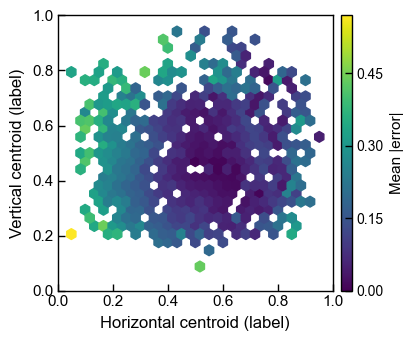

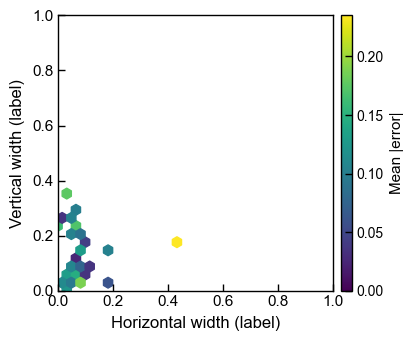

In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from mpl_toolkits.axes_grid1 import make_axes_locatable
from xflow.extensions.style.aps import set_aps_double_column

# =========================================================
# Font / tick size controls
# =========================================================
TICK_LABEL_SIZE   = 11   # x/y tick numbers on the main axes
AXIS_LABEL_SIZE   = 12   # x/y axis labels
CBAR_TICK_SIZE    = 10   # colorbar tick numbers
CBAR_LABEL_SIZE   = 11   # colorbar label ("Mean |error|")
CBAR_NUM_TICKS    = 5    # target number of colorbar ticks (MaxNLocator picks nice values near this)
TICK_MAJOR_LEN    = 5
TICK_MINOR_LEN    = 3
TICK_WIDTH        = 1.0


# =========================================================
# Error column module
# error_gaussian_{dim}_{param} = label - prediction
# =========================================================
def add_gaussian_error_columns(df):
    out = df.copy()
    for dim, param in _DIMS_PARAMS:
        label_col = f"label_gaussian_{dim}_{param}"
        pred_col  = f"reconstructed_gaussian_{dim}_{param}"
        err_col   = f"error_gaussian_{dim}_{param}"
        out[err_col] = (
            pd.to_numeric(out[label_col], errors="coerce")
            - pd.to_numeric(out[pred_col], errors="coerce")
        )
    return out


# =========================================================
# Hexbin: label_h vs label_v, color = mean |error|
# =========================================================
def plot_hex_error_2d(
    df,
    param_type="centroid",      # "centroid" or "width"
    gridsize=25,                # hexagon size control
    xlim=(0.0, 1.0),
    ylim=(0.0, 1.0),
    range_mode="full",          # "full": use xlim/ylim as given (default).
                                # "tight": auto-scale to data min/max, shared square range.
    cmap="viridis",
    vmax=None,
    figsize=(3.8, 3.8),
):
    x   = df[f"label_gaussian_h_{param_type}"].to_numpy()
    y   = df[f"label_gaussian_v_{param_type}"].to_numpy()
    e_h = df[f"error_gaussian_h_{param_type}"].to_numpy()
    e_v = df[f"error_gaussian_v_{param_type}"].to_numpy()
    mae = 0.5 * (np.abs(e_h) + np.abs(e_v))

    # Resolve plot range.
    # "full"  → keep user-provided xlim/ylim (normalized [0,1] by default).
    # "tight" → compute a shared [lo, hi] over x and y so the box stays square
    #           under set_aspect("equal") + set_box_aspect(1), with small padding.
    if range_mode == "tight":
        lo = float(min(x.min(), y.min()))
        hi = float(max(x.max(), y.max()))
        pad = 0.02 * (hi - lo) if hi > lo else 0.01
        xlim = (lo - pad, hi + pad)
        ylim = xlim

    set_aps_double_column(figsize=figsize, scale=1.0, legend_background=True)
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_box_aspect(1)

    hb = ax.hexbin(
        x, y, C=mae,
        reduce_C_function=np.mean,
        gridsize=gridsize,
        cmap=cmap,
        extent=(xlim[0], xlim[1], ylim[0], ylim[1]),
        vmin=0.0, vmax=vmax,
        mincnt=1,
    )

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(f"Horizontal {param_type} (label)", fontsize=AXIS_LABEL_SIZE)
    ax.set_ylabel(f"Vertical {param_type} (label)",   fontsize=AXIS_LABEL_SIZE)
    # ax.set_title(f"Gaussian | {param_type.capitalize()}")

    ax.tick_params(
        axis="both", which="major",
        labelsize=TICK_LABEL_SIZE,
        length=TICK_MAJOR_LEN, width=TICK_WIDTH,
    )
    ax.tick_params(
        axis="both", which="minor",
        length=TICK_MINOR_LEN, width=TICK_WIDTH,
    )

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4%", pad=0.08)
    cb = fig.colorbar(hb, cax=cax)
    cb.set_label("Mean |error|", fontsize=CBAR_LABEL_SIZE)

    # Colorbar tick count + tick label size
    cb.locator = MaxNLocator(nbins=CBAR_NUM_TICKS)
    cb.update_ticks()
    cb.ax.tick_params(labelsize=CBAR_TICK_SIZE, length=TICK_MAJOR_LEN, width=TICK_WIDTH)

    return fig, ax


gridsize = 30
range_mode = "full"   # "full" or "tight"
SAVE_PREFIX = "_"

save_dir = dirs["save"]["model_inference"][MODEL_NAME]
csv_path = os.path.join(save_dir, "beam_parameters.csv")

df = load_beam_param_df(csv_path)
df = add_gaussian_error_columns(df)
df = drop_invalid_rows(df)   # blanket clean: drop any row with NaN/inf anywhere

fig_c, _ = plot_hex_error_2d(df, param_type="centroid", gridsize=gridsize, range_mode=range_mode)
fig_w, _ = plot_hex_error_2d(df, param_type="width",    gridsize=gridsize, range_mode=range_mode)

fig_c.savefig(os.path.join(save_dir, f"{SAVE_PREFIX}gaussian_centroid_hex_error.png"), bbox_inches="tight")
fig_w.savefig(os.path.join(save_dir, f"{SAVE_PREFIX}gaussian_width_hex_error.png"), bbox_inches="tight")

# Statistical overview of entire testset

In [9]:
import json
import numpy as np
import pandas as pd
import os

# Metric registry for beam-parameter regression targets.
# Each metric takes (y_true, y_pred) as 1D numpy arrays and returns a float.
def _r2_safe(y, yh):
    denom = np.sum((y - np.mean(y)) ** 2)
    if denom <= 0:
        return float("nan")
    return float(1.0 - np.sum((y - yh) ** 2) / denom)

_METRICS = {
    "mse":       lambda y, yh: float(np.mean((y - yh) ** 2)),
    "rmse":      lambda y, yh: float(np.sqrt(np.mean((y - yh) ** 2))),
    "mae":       lambda y, yh: float(np.mean(np.abs(y - yh))),
    "medae":     lambda y, yh: float(np.median(np.abs(y - yh))),
    "max_error": lambda y, yh: float(np.max(np.abs(y - yh))),
    "r2":        _r2_safe,
}

def compute_fit_metrics(
    df,
    fit_methods=("gaussian", "moments"),
    metrics=("rmse", "mse"),
    save_path=None,
):
    """
    Compute beam-parameter metrics:
      {fit_method}_{dim}_{param}_{metric}
    e.g. gaussian_h_centroid_rmse
    """
    unknown = [m for m in metrics if m not in _METRICS]
    if unknown:
        raise ValueError(f"Unknown metrics: {unknown}. Available: {sorted(_METRICS)}")

    results = {}
    for fit_method in fit_methods:
        for dim, param in _DIMS_PARAMS:
            y_col = f"label_{fit_method}_{dim}_{param}"
            yh_col = f"reconstructed_{fit_method}_{dim}_{param}"

            if y_col not in df.columns or yh_col not in df.columns:
                raise KeyError(f"Missing required columns: {y_col} or {yh_col}")

            y = pd.to_numeric(df[y_col], errors="coerce").to_numpy(dtype=float)
            yh = pd.to_numeric(df[yh_col], errors="coerce").to_numpy(dtype=float)

            m = np.isfinite(y) & np.isfinite(yh)
            y, yh = y[m], yh[m]

            for metric_name in metrics:
                key = f"{fit_method}_{dim}_{param}_{metric_name}"
                if y.size == 0:
                    results[key] = float("nan")
                else:
                    results[key] = _METRICS[metric_name](y, yh)

    if save_path is not None:
        with open(save_path, "w") as f:
            json.dump(results, f, indent=2)

    return results

def append_image_metrics(
    results,
    df,
    image_cols=None,
    agg="mean",
):
    """
    Append image-level metrics from per-sample columns already in df.
    Defaults:
      reconstructed_label_psnr -> image_psnr
      reconstructed_label_ssim -> image_ssim
      reconstructed_label_mae  -> image_pixelmae
    """
    if image_cols is None:
        image_cols = {
            "reconstructed_label_psnr": "image_psnr",
            "reconstructed_label_ssim": "image_ssim",
            "reconstructed_label_mae": "image_pixelmae",  # avoid suffix '_mae' collision
        }

    if agg not in ("mean", "median"):
        raise ValueError("agg must be 'mean' or 'median'")

    reducer = np.mean if agg == "mean" else np.median

    for col, out_key in image_cols.items():
        if col not in df.columns:
            results[out_key] = float("nan")
            continue

        x = pd.to_numeric(df[col], errors="coerce").to_numpy(dtype=float)
        x = x[np.isfinite(x)]
        results[out_key] = float(reducer(x)) if x.size > 0 else float("nan")

    return results

def compute_fit_and_image_metrics(
    df,
    fit_methods=("gaussian", "moments"),
    metrics=("rmse", "mae", "r2", "mse"),
    image_cols=None,
    image_agg="mean",
    save_path=None,
):
    """
    Wrapper:
    1) compute beam-parameter metrics
    2) append image-level metrics
    3) save one merged JSON
    """
    results = compute_fit_metrics(
        df=df,
        fit_methods=fit_methods,
        metrics=metrics,
        save_path=None,  # save after merge
    )

    results = append_image_metrics(
        results=results,
        df=df,
        image_cols=image_cols,
        agg=image_agg,
    )

    if save_path is not None:
        with open(save_path, "w") as f:
            json.dump(results, f, indent=2)

    return results


save_dir = dirs["save"]["model_inference"][MODEL_NAME]
csv_path = os.path.join(save_dir, "beam_parameters.csv")
df = load_beam_param_df(csv_path)
df = drop_invalid_rows(df)

metrics_dict = compute_fit_and_image_metrics(
    df,
    fit_methods=("gaussian", "moments"),
    metrics=("rmse", "mae", "r2", "mse"),
    image_cols={
        "reconstructed_label_psnr": "image_psnr",
        "reconstructed_label_ssim": "image_ssim",
        "reconstructed_label_mae": "image_pixelmae",
    },
    image_agg="mean",  # or "median"
    save_path=os.path.join(save_dir, f"{SAVE_PREFIX}fit_metrics.json"),
)

metrics_dict

{'gaussian_h_centroid_rmse': 0.24464259721799436,
 'gaussian_h_centroid_mae': 0.17733790689560588,
 'gaussian_h_centroid_r2': -0.42451530674754,
 'gaussian_h_centroid_mse': 0.059850000373565825,
 'gaussian_v_centroid_rmse': 0.13595106641554808,
 'gaussian_v_centroid_mae': 0.09427892539332432,
 'gaussian_v_centroid_r2': 0.3924388468874239,
 'gaussian_v_centroid_mse': 0.018482692459524767,
 'gaussian_h_width_rmse': 0.16259273494074677,
 'gaussian_h_width_mae': 0.10451263602911735,
 'gaussian_h_width_r2': -78.52597718312892,
 'gaussian_h_width_mse': 0.026436397455511934,
 'gaussian_v_width_rmse': 0.2072168750989489,
 'gaussian_v_width_mae': 0.11805773908237621,
 'gaussian_v_width_r2': -57.25150296960057,
 'gaussian_v_width_mse': 0.04293883332577338,
 'moments_h_centroid_rmse': 0.17396877194036675,
 'moments_h_centroid_mae': 0.14216510371337124,
 'moments_h_centroid_r2': 0.01197246408595476,
 'moments_h_centroid_mse': 0.030265133610439338,
 'moments_v_centroid_rmse': 0.13436948529644063,
 

# Cross model summary
this part read final statistics across different run and give a final conclusion

In [10]:
from pathlib import Path
import json
import pandas as pd
from xflow.utils.io import scan_files

def collect_fit_metrics(
    root_dir,
    save_csv=True,
    csv_name="cross_model_fit_metrics_summary.csv",
):
    root_dir = Path(root_dir)

    all_json = scan_files(root_dir, extensions=".json", return_type="path", recursive=True)
    metric_files = [Path(p) for p in all_json if Path(p).name == "_fit_metrics.json"]

    rows = []
    for fp in metric_files:
        with open(fp, "r", encoding="utf-8") as f:
            row = json.load(f)  # assumes same keys across all files
        row["model"] = fp.parent.parent.name  # .../<model>/inference/_fit_metrics.json
        rows.append(row)

    if not rows:
        return pd.DataFrame()

    df = pd.DataFrame(rows).set_index("model").sort_index()

    if save_csv:
        out_csv = root_dir / csv_name
        df.to_csv(out_csv, index=True)
        print(f"Saved CSV: {out_csv}")

    return df

# usage
root_dir = dirs["models"]["root"]
df = collect_fit_metrics(root_dir)
df

Saved CSV: C:\Users\qiyuanxu\Desktop\Models\cross_model_fit_metrics_summary.csv


,gaussian_h_centroid_rmse,gaussian_h_centroid_mae,gaussian_h_centroid_r2,gaussian_h_centroid_mse,gaussian_v_centroid_rmse,gaussian_v_centroid_mae,gaussian_v_centroid_r2,gaussian_v_centroid_mse,gaussian_h_width_rmse,gaussian_h_width_mae,...,moments_h_width_mae,moments_h_width_r2,moments_h_width_mse,moments_v_width_rmse,moments_v_width_mae,moments_v_width_r2,moments_v_width_mse,image_psnr,image_ssim,image_pixelmae
model,,,,,,,,,,,,,,,,,,,,,
Model_trained_on_CHROMOX_LASER_only,0.244643,0.177338,-0.424515,0.059850,0.135951,0.094279,0.392439,0.018483,0.162593,0.104513,...,0.161346,-12.304406,0.027587,0.176414,0.171921,-15.258982,0.031122,30.396438,0.496326,0.001783
Model_trained_on_CHROMOX_only,0.165972,0.071849,0.037143,0.027547,0.109800,0.049613,0.625436,0.012056,0.068744,0.023336,...,0.040798,0.211948,0.002219,0.049305,0.045772,0.101199,0.002431,32.606514,0.648802,0.000819
Model_trained_on_DMD_orth_SGM_inLab_150MB,0.018266,0.011173,0.977714,0.000334,0.006628,0.005150,0.998187,0.000044,0.026441,0.016230,...,0.086278,-7.086432,0.008811,0.111911,0.109647,-15.639118,0.012524,28.865033,0.852303,0.006634
chromox_cae_random_scan,0.131530,0.054306,0.595587,0.017300,0.076664,0.034035,0.837921,0.005877,0.141254,0.046419,...,0.107860,-4.315020,0.013548,0.108071,0.102505,-5.343588,0.011679,34.402557,0.746539,0.001714
chromox_cropped_cae_line_scan_sgm,0.134590,0.065878,0.685461,0.018115,0.138865,0.069552,0.714682,0.019283,0.095839,0.043513,...,0.128056,-4.532682,0.018512,0.128608,0.119493,-3.155265,0.016540,27.156397,0.553458,0.006753
chromox_cropped_cae_random_scan,0.037370,0.017595,0.974612,0.001396,0.068777,0.022672,0.924622,0.004730,0.040987,0.013949,...,0.074904,-1.004717,0.006973,0.080820,0.070247,-0.666290,0.006532,33.359713,0.860269,0.003340
chromox_cropped_cae_random_scan_leakless,0.070247,0.035264,0.913491,0.004935,0.093399,0.044848,0.870717,0.008723,0.068294,0.028005,...,0.109802,-3.207911,0.014296,0.111727,0.101174,-2.315249,0.012483,29.186555,0.665192,0.005612


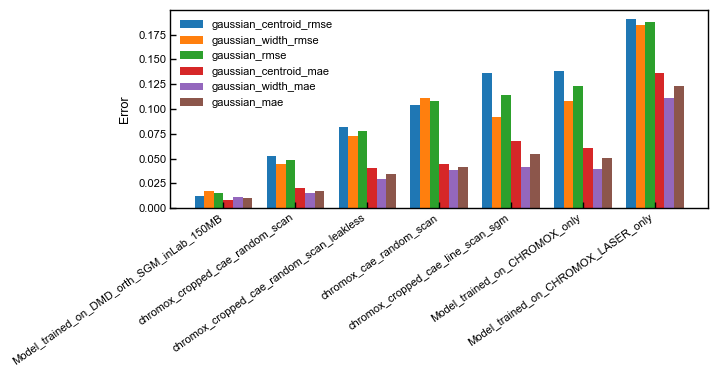

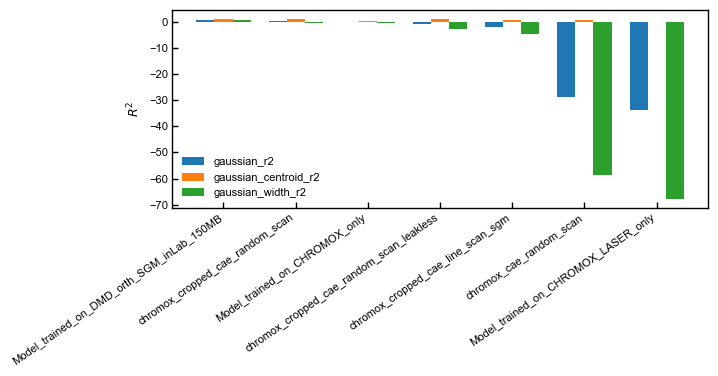

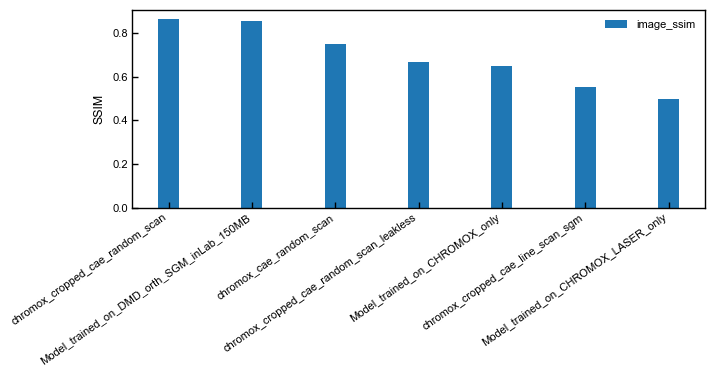

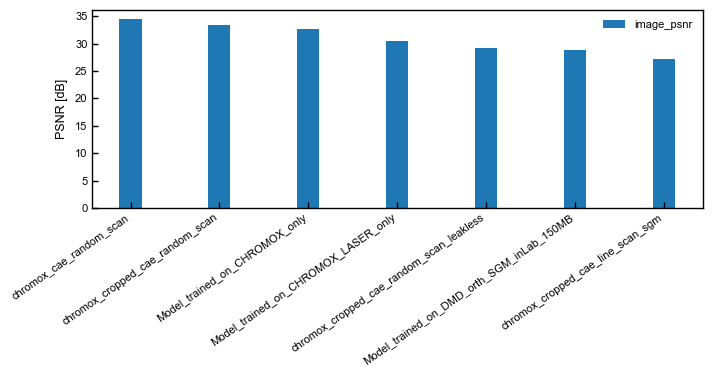

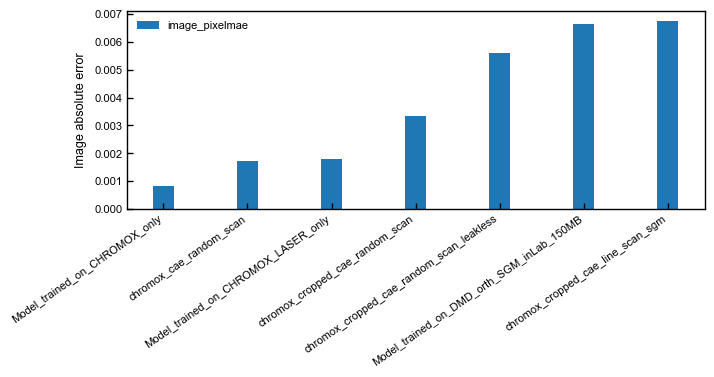

In [27]:
from __future__ import annotations

from collections import OrderedDict
from typing import Callable, Iterable, Optional

from xflow.extensions.style.aps import set_aps_double_column as set_aps_style

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# -----------------------------
# 1. Aggregation / padding layer
# -----------------------------

def add_fit_metric_aggregates(
    df: pd.DataFrame,
    methods: Iterable[str] = ("gaussian",),
    metrics: Optional[Iterable[str]] = None,
    strict: bool = True,
) -> pd.DataFrame:
    """Return a new dataframe with aggregate fit-metric columns.

    Expected input columns:

        {method}_{axis}_{parameter}_{metric}

    Examples:
        gaussian_h_centroid_rmse
        gaussian_v_centroid_rmse
        gaussian_h_width_rmse
        gaussian_v_width_rmse

    Added columns:
        {method}_centroid_{metric}
        {method}_width_{metric}
        {method}_{metric}
    """
    out = df.copy(deep=True)

    if metrics is None:
        metrics = _infer_fit_metrics(out.columns, methods)

    for method in methods:
        for metric in metrics:
            centroid_cols = [
                f"{method}_h_centroid_{metric}",
                f"{method}_v_centroid_{metric}",
            ]
            width_cols = [
                f"{method}_h_width_{metric}",
                f"{method}_v_width_{metric}",
            ]
            all_cols = centroid_cols + width_cols

            _check_columns(out, all_cols, strict=strict)

            available_centroid_cols = [c for c in centroid_cols if c in out.columns]
            available_width_cols = [c for c in width_cols if c in out.columns]
            available_all_cols = [c for c in all_cols if c in out.columns]

            if available_centroid_cols:
                out[f"{method}_centroid_{metric}"] = out[available_centroid_cols].mean(axis=1)

            if available_width_cols:
                out[f"{method}_width_{metric}"] = out[available_width_cols].mean(axis=1)

            if available_all_cols:
                out[f"{method}_{metric}"] = out[available_all_cols].mean(axis=1)

    return out


def _infer_fit_metrics(columns: Iterable[str], methods: Iterable[str]) -> list[str]:
    """Infer available metric suffixes from fit-parameter columns."""
    metrics = set()

    for col in columns:
        for method in methods:
            prefix_parts = [
                f"{method}_h_centroid_",
                f"{method}_v_centroid_",
                f"{method}_h_width_",
                f"{method}_v_width_",
            ]

            for prefix in prefix_parts:
                if col.startswith(prefix):
                    metrics.add(col.removeprefix(prefix))

    return sorted(metrics)


def _check_columns(df: pd.DataFrame, columns: Iterable[str], strict: bool) -> None:
    missing = [c for c in columns if c not in df.columns]

    if strict and missing:
        raise KeyError(f"Missing expected columns: {missing}")


# -----------------------------
# 2. Metric scale grouping layer
# -----------------------------

def group_metrics_by_scale(metrics: Iterable[str]) -> OrderedDict[str, list[str]]:
    """Group metric columns that can reasonably share one y-axis."""
    groups: OrderedDict[str, list[str]] = OrderedDict()

    for metric in metrics:
        scale_key = infer_metric_scale(metric)
        groups.setdefault(scale_key, []).append(metric)

    return groups


def infer_metric_scale(metric: str) -> str:
    """Infer which y-scale family a metric belongs to."""
    metric_lower = metric.lower()

    if metric_lower.endswith("_r2"):
        return "r2"

    if metric_lower.endswith("_mse"):
        return "mse"

    if (
        metric_lower.endswith("_rmse")
        or metric_lower.endswith("_mae")
        or metric_lower.endswith("_medae")
        or metric_lower.endswith("_max_error")
    ):
        if metric_lower.startswith("image_"):
            return "image_absolute_error"
        return "fit_absolute_error"

    if metric_lower == "image_pixelmae":
        return "image_absolute_error"

    if metric_lower == "image_ssim":
        return "ssim"

    if metric_lower == "image_psnr":
        return "psnr_db"

    return "other"


# -----------------------------
# 3. Ranking layer
# -----------------------------

def infer_higher_is_better(metric: str) -> bool:
    """Infer whether larger values are better for a metric."""
    metric_lower = metric.lower()

    higher_better_metrics = (
        "_r2",
        "_ssim",
        "_psnr",
    )

    lower_better_metrics = (
        "_mse",
        "_rmse",
        "_mae",
        "_medae",
        "_max_error",
        "pixelmae",
    )

    if metric_lower.endswith(higher_better_metrics):
        return True

    if metric_lower.endswith(lower_better_metrics) or "pixelmae" in metric_lower:
        return False

    # Conservative default: lower is better for unknown error-like values.
    return False


def sort_by_metric(
    df: pd.DataFrame,
    metric: str,
    higher_is_better: Optional[bool] = None,
) -> pd.DataFrame:
    """Return a new dataframe sorted best-to-worst by one metric."""
    if higher_is_better is None:
        higher_is_better = infer_higher_is_better(metric)

    return df.sort_values(
        by=metric,
        ascending=not higher_is_better,
        na_position="last",
    ).copy(deep=True)


# -----------------------------
# 4. Plotting layer
# -----------------------------

def plot_metric_bars(
    df: pd.DataFrame,
    metrics: list[str],
    model_col: str = "model",
    model_order: Optional[list[str]] = None,
    model_label_map: Optional[dict[str, str]] = None,
    metric_label_map: Optional[dict[str, str]] = None,
    split_by_scale: bool = True,
    rank_models: bool = False,
    rank_by: Optional[str] = None,
    higher_is_better: Optional[dict[str, bool]] = None,
    style_func: Optional[Callable[[], None]] = None,
    figsize: tuple[float, float] = (7.2, 3.8),
    rotation: int = 35,
) -> list[tuple[plt.Figure, plt.Axes]]:
    """Plot grouped bar charts for selected metrics.

    Ranking logic:
        - If model_order is provided, use model_order.
        - Else if rank_models=True, rank each plot by rank_by.
        - If rank_by=None, rank by the first metric in that plot.
    """
    metrics = [m for m in metrics if m]  # remove empty placeholders like ""

    if not metrics:
        raise ValueError("No valid metrics were provided.")

    plot_df = df.copy(deep=True)

    # Allow model names to be stored as index.
    if model_col not in plot_df.columns:
        if plot_df.index.name == model_col:
            plot_df = plot_df.reset_index()
        else:
            raise KeyError(
                f"Missing model column '{model_col}'. "
                f"Available columns: {list(plot_df.columns)}. "
                f"Index name: {plot_df.index.name}"
            )

    _check_columns(plot_df, [model_col] + metrics, strict=True)

    if style_func is not None:
        style_func()

    if model_order is not None:
        plot_df[model_col] = pd.Categorical(
            plot_df[model_col],
            categories=model_order,
            ordered=True,
        )
        plot_df = plot_df.sort_values(model_col)

    if split_by_scale:
        metric_groups = group_metrics_by_scale(metrics)
    else:
        metric_groups = OrderedDict({"selected_metrics": metrics})

    figs_axes = []

    for scale_key, group_metrics in metric_groups.items():
        this_plot_df = plot_df.copy(deep=True)

        if model_order is None and rank_models:
            this_rank_metric = rank_by or group_metrics[0]

            if this_rank_metric not in this_plot_df.columns:
                raise KeyError(f"Ranking metric not found: {this_rank_metric}")

            metric_higher_is_better = None
            if higher_is_better is not None:
                metric_higher_is_better = higher_is_better.get(this_rank_metric)

            this_plot_df = sort_by_metric(
                this_plot_df,
                metric=this_rank_metric,
                higher_is_better=metric_higher_is_better,
            )

        fig, ax = plt.subplots(figsize=figsize)

        _plot_one_grouped_bar_chart(
            ax=ax,
            df=this_plot_df,
            metrics=group_metrics,
            model_col=model_col,
            model_label_map=model_label_map,
            metric_label_map=metric_label_map,
        )

        ax.set_ylabel(_default_ylabel(scale_key))
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=rotation)
        ax.legend(frameon=False)
        fig.tight_layout()

        figs_axes.append((fig, ax))

    return figs_axes


def _plot_one_grouped_bar_chart(
    ax: plt.Axes,
    df: pd.DataFrame,
    metrics: list[str],
    model_col: str,
    model_label_map: Optional[dict[str, str]],
    metric_label_map: Optional[dict[str, str]],
) -> None:
    x = np.arange(len(df))
    n_metrics = len(metrics)
    bar_width = min(0.8 / max(n_metrics, 1), 0.25)

    model_labels = df[model_col].astype(str).tolist()
    if model_label_map is not None:
        model_labels = [model_label_map.get(x, x) for x in model_labels]

    offsets = (np.arange(n_metrics) - (n_metrics - 1) / 2) * bar_width

    for i, metric in enumerate(metrics):
        label = metric_label_map.get(metric, metric) if metric_label_map else metric

        ax.bar(
            x + offsets[i],
            df[metric].to_numpy(dtype=float),
            width=bar_width,
            label=label,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(model_labels, ha="right")


def _default_ylabel(scale_key: str) -> str:
    labels = {
        "fit_absolute_error": "Error",
        "image_absolute_error": "Image absolute error",
        "mse": "MSE",
        "r2": r"$R^2$",
        "ssim": "SSIM",
        "psnr_db": "PSNR [dB]",
        "other": "Value",
        "selected_metrics": "Value",
    }
    return labels.get(scale_key, "Value")


# -----------------------------
# 5. Example usage
# -----------------------------

df_plot = add_fit_metric_aggregates(
    df,
    methods=("gaussian", "moments"),
    metrics=("rmse", "mae", "mse", "r2"),
)

if "model" not in df_plot.columns:
    df_plot = df_plot.reset_index()

metrics_to_plot = [
    "gaussian_centroid_rmse",
    "gaussian_width_rmse",
    "gaussian_rmse",
    "gaussian_centroid_mae",
    "gaussian_width_mae",
    "gaussian_mae",
    "gaussian_r2",
    "gaussian_centroid_r2",
    "gaussian_width_r2",
    "image_ssim",
    "image_psnr",
    "image_pixelmae",
]

figs_axes = plot_metric_bars(
    df_plot,
    metrics=metrics_to_plot,
    model_col="model",
    rank_models=True,
    style_func=set_aps_style,
)